In [ ]:
import numpy as np
import pandas as pd
import plotly.express as px
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns


import sys
sys.path.append("../..")
from src.utils import mark_repeated_columns
from src.plotting import plot_acf_pacf
from src.dynamicFPC import super_fun

# Configs
import plotly.io as pio
pio.templates.default = "plotly_dark"
pio.renderers.default = "notebook_connected"

In [2]:
def lag_matrix(x, L):
    df = pd.concat([x.shift(i) for i in range(0, L + 1)], axis=1)
    df.columns = [f"{x.name}_t-{i}" for i in range(0, L + 1)]
    return df.dropna()

In [3]:
LOG_VOLATILITY:bool = True # if false, doesn't apply log to realized volatility.
DHAT = 5 # number of the dimensions from dFPC to keep and work with

# Data

In [4]:
data_path = "../../data/processed/"
returns_path = ''.join([data_path, 'ibovespa_treated.xlsx'])
df_ibovespa = pd.read_excel(returns_path, index_col="time")#.loc[:,"r_t"]
df_ibovespa.head()

,2024-12-02,2024-12-03,2024-12-04,2024-12-05,2024-12-06,2024-12-09,2024-12-10,2024-12-11,2024-12-12,2024-12-13,...,2025-11-14,2025-11-17,2025-11-18,2025-11-19,2025-11-21,2025-11-24,2025-11-25,2025-11-26,2025-11-27,2025-11-28
time,,,,,,,,,,,,,,,,,,,,,
10:05:00,-0.002271,0.003372,0.001716,0.005538,0.000069,0.006429,0.002343,0.001918,-0.007582,-0.000413,...,-0.001522,0.000739,-0.000613,0.000306,-0.002021,-0.000810,0.001557,-0.001565,-0.000193,0.002906
10:10:00,-0.000582,0.002832,-0.000502,0.000739,0.000261,0.001891,0.000775,-0.001172,0.000216,-0.000432,...,0.000360,-0.000105,-0.000159,-0.000362,0.000092,0.001131,0.001170,0.000202,0.000556,0.000475
10:15:00,-0.001997,0.001091,0.000111,-0.000192,0.000407,-0.001392,-0.000477,-0.001526,0.000198,-0.001821,...,0.001121,-0.000284,0.003272,-0.001107,-0.001012,-0.000174,0.001002,0.001815,-0.000168,0.000973
10:20:00,-0.000037,-0.000505,-0.000327,-0.000580,-0.000436,-0.000405,0.001263,0.000676,-0.002667,0.001033,...,0.000449,0.000335,0.000853,0.000981,-0.000057,-0.000096,0.000832,0.001951,0.001060,-0.001004
10:25:00,0.000364,-0.001532,0.000429,-0.000426,-0.000162,-0.000130,0.000060,0.000818,-0.000970,0.000670,...,-0.000871,-0.000559,0.001030,-0.000749,-0.001194,0.001338,0.000128,0.001279,-0.000162,-0.000651


# Exploratory analysis

In [5]:
df_squared_returns = df_ibovespa**2
realized_volatility = df_squared_returns.sum(axis=0)
if LOG_VOLATILITY:
    realized_volatility = np.log(realized_volatility)
realized_volatility.name = "realized_volatility"
realized_volatility.index.name = "date"

In [6]:
fig = px.line(
    df_ibovespa,
    color_discrete_sequence=['#80ed99'],  
    title="Returns by tick")

fig.update_layout(
    legend_title_text='Curve'
)
fig.update_traces(opacity=.4)
fig.show()

In [7]:
fig = px.line(
    df_squared_returns,
    color_discrete_sequence=['#80ed99'],
    title="Squared returns"
    )

fig.update_layout(
    legend_title_text='Curve'
)
fig.update_traces(opacity=.4)
fig.update_layout(yaxis=dict(exponentformat='power'))
fig.show()

In [8]:
fig = px.line(
    realized_volatility,
    color_discrete_sequence=['#80ed99'],
    title="Log Realized volatility" if LOG_VOLATILITY else "Realized volatility"
    )

fig.update_layout(
    # legend_title_text='Curve',
    showlegend=False
)

fig.update_layout(yaxis=dict(exponentformat='power'))
fig.show()

In [9]:
#realized_volatility.to_excel("../../data/processed/ibovespa_realized_volatility.xlsx")

In [10]:

acf_values = sm.tsa.stattools.acf(realized_volatility, nlags=100)
n = len(realized_volatility)
conf_interval = 1.96 / np.sqrt(n)
significant_acf_lags = np.where(np.abs(acf_values[1:]) > conf_interval)[0] + 1
print("Significant ACF Lags:", significant_acf_lags)

pacf_values = sm.tsa.stattools.pacf(realized_volatility, nlags=100)
significant_pacf_lags = np.where(np.abs(pacf_values[1:]) > conf_interval)[0] + 1
print("Significant PACF Lags:", significant_pacf_lags)

Significant ACF Lags: [ 1  2  3  4  5  6  7 21 22 78]
Significant PACF Lags: [ 1  2  3 20 23 67 71 78 87 97]


In [11]:
# AUTOCORRELATION
title = f"Correlation analysis"
max_lag = np.hstack([significant_acf_lags,significant_pacf_lags]).max() + 5
plot_acf_pacf(
        realized_volatility, 
        title=title,
        nlags=max_lag
        )

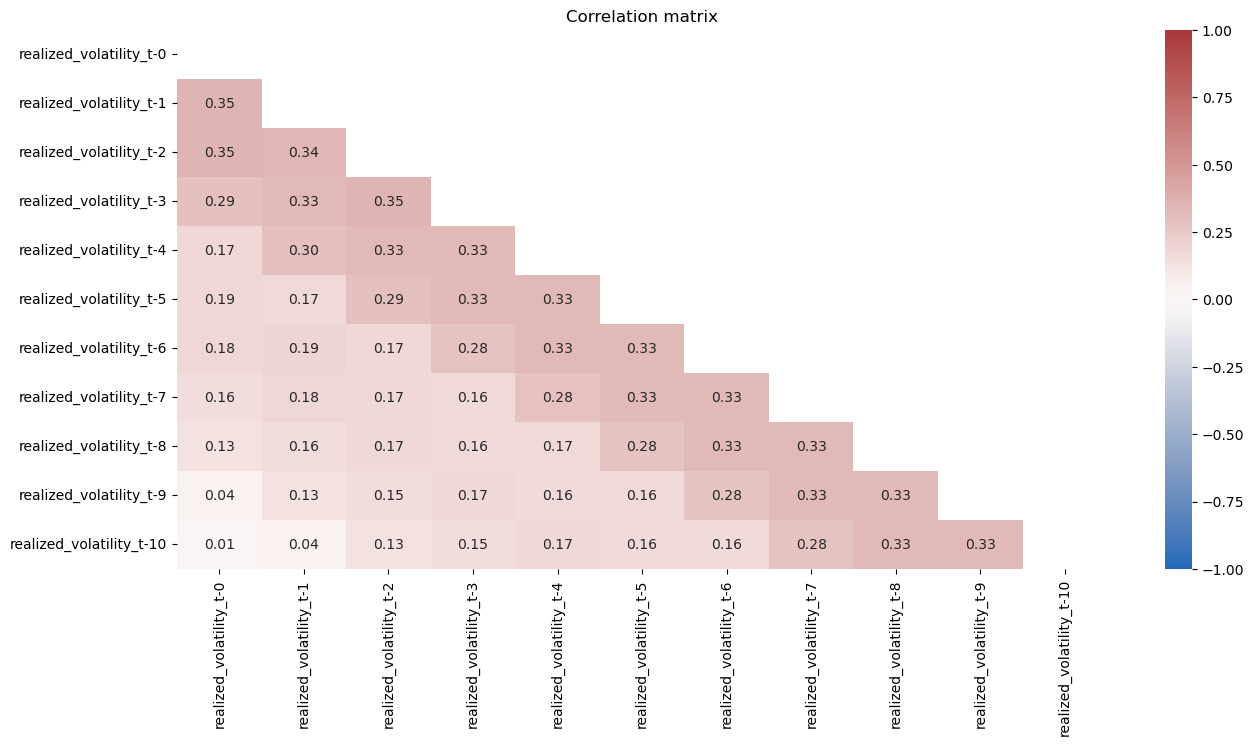

In [12]:
N_VOLATILITY_LAGS = 10
realized_volatility_lags = lag_matrix(realized_volatility,N_VOLATILITY_LAGS)

plt.figure(figsize=(15,7))
corr_matrix = realized_volatility_lags.corr(method="pearson")
matrix = np.triu(corr_matrix)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="vlag", cbar=True, mask=matrix, vmin=-1, vmax=1)
plt.title("Correlation matrix")
plt.show()


In [13]:
fig = px.scatter_matrix(
    realized_volatility_lags,
    width=1000,
    height=1000
    )
fig.update_traces(showlowerhalf=False)
fig.show()

In [14]:
fig = px.scatter(
    x=realized_volatility.shift(1),
    y=realized_volatility, 
    title="$(\hat{\zeta}_{t-1}, \hat{\zeta}_t)$",
    trendline="ols"
    )
fig.show()

# Scores

In [15]:
scores_path = "../../data/processed/dfpc_scores.xlsx"
df_scores = pd.read_excel(scores_path).set_index("index").iloc[:,:DHAT]

In [16]:
df_vol_scores = pd.concat([realized_volatility, df_scores], axis=1)
# Adds 1 lag
for eta in df_scores.columns:
    col_name = eta.replace("$","")
    df_vol_scores[f"{col_name}_t-1"] = df_vol_scores[eta].shift(1)
df_vol_scores.dropna(inplace=True)

corr_matrix = df_vol_scores.corr(method="pearson")
display(corr_matrix)

upper_indices = np.triu_indices_from(corr_matrix, k=1)
sorted_list = np.sort(np.abs(corr_matrix).values[upper_indices])[::-1].tolist()
print("Top absolute correlations: ", sorted_list)

,realized_volatility,$η_1$,$η_2$,$η_3$,$η_4$,$η_5$,η_1_t-1,η_2_t-1,η_3_t-1,η_4_t-1,η_5_t-1
realized_volatility,1.000000,0.916491,-0.004610,-0.191350,-0.253203,0.130879,0.385543,0.033271,-0.042151,0.009677,-0.063510
$η_1$,0.916491,1.000000,-0.076831,0.015050,-0.104095,0.150936,0.459067,-0.059391,-0.011020,0.054920,-0.034998
$η_2$,-0.004610,-0.076831,1.000000,0.032853,0.280589,-0.362226,-0.090077,0.158479,-0.010132,-0.066262,-0.092207
$η_3$,-0.191350,0.015050,0.032853,1.000000,0.282545,-0.132769,0.004616,-0.113750,0.215266,0.112821,0.005938
$η_4$,-0.253203,-0.104095,0.280589,0.282545,1.000000,-0.057515,-0.062774,-0.016498,0.013712,-0.016942,-0.006670
$η_5$,0.130879,0.150936,-0.362226,-0.132769,-0.057515,1.000000,0.103509,-0.084037,-0.051918,-0.063554,0.040172
η_1_t-1,0.385543,0.459067,-0.090077,0.004616,-0.062774,0.103509,1.000000,-0.084490,0.020932,-0.106074,0.147399
η_2_t-1,0.033271,-0.059391,0.158479,-0.113750,-0.016498,-0.084037,-0.084490,1.000000,0.016099,0.276508,-0.359245
η_3_t-1,-0.042151,-0.011020,-0.010132,0.215266,0.013712,-0.051918,0.020932,0.016099,1.000000,0.277637,-0.138689
η_4_t-1,0.009677,0.054920,-0.066262,0.112821,-0.016942,-0.063554,-0.106074,0.276508,0.277637,1.000000,-0.058836


Top absolute correlations:  [0.9164913173222068, 0.4590674725727362, 0.38554283976162773, 0.3622260911515144, 0.3592449840317531, 0.2825451608977297, 0.28058895473201656, 0.27763742325427365, 0.27650832126813724, 0.25320274561383843, 0.21526560545198356, 0.19135032829230364, 0.15847913235893543, 0.1509358883620096, 0.14739930148034477, 0.13868879210058102, 0.1327689421281718, 0.1308793282397958, 0.11375011309563661, 0.11282070665613433, 0.10607426532030736, 0.10409495054561078, 0.10350922293043348, 0.09220721675110252, 0.09007682623997697, 0.08448954844094678, 0.08403700799044496, 0.07683087039639008, 0.06626205192878282, 0.06355380999043297, 0.06351039746679712, 0.06277388153634962, 0.05939149592978096, 0.05883645585239909, 0.05751538557283658, 0.05492020799820946, 0.05191804252079226, 0.04215124736506629, 0.0401716141492008, 0.03499792570002184, 0.03327053038729549, 0.03285271828764267, 0.02093206844453553, 0.01694179897384102, 0.016497743636697322, 0.01609857339006231, 0.01504958075

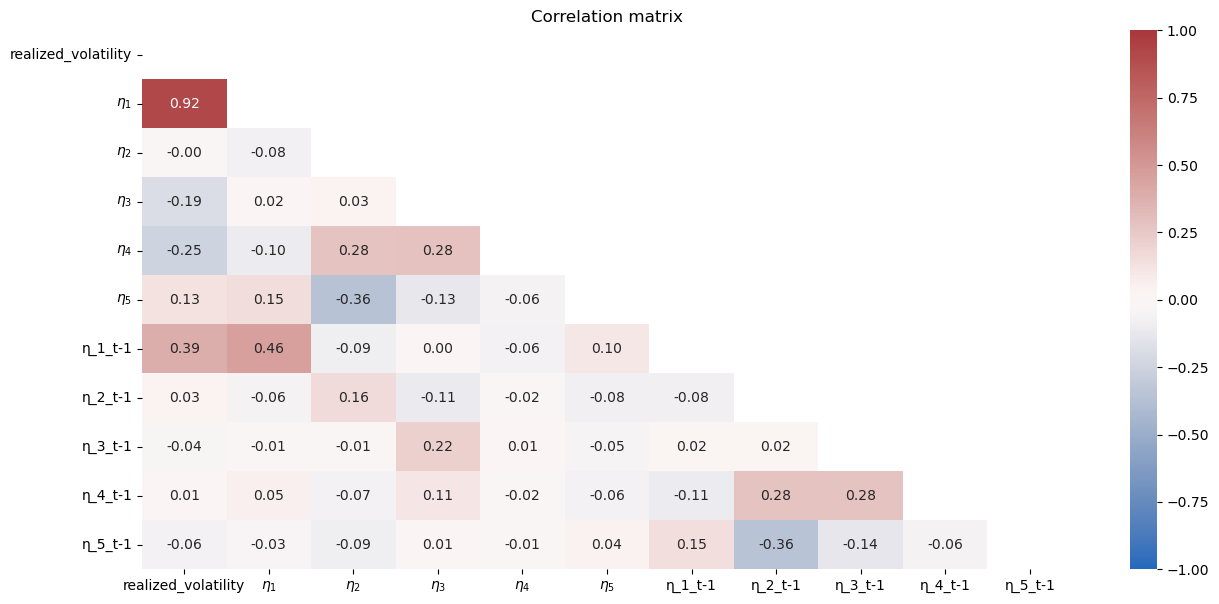

In [17]:
corr_matrix = df_vol_scores.corr()

plt.figure(figsize=(15,7))
matrix = np.triu(corr_matrix)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="vlag", cbar=True, mask=matrix, vmin=-1, vmax=1)
plt.title("Correlation matrix")
plt.show()

In [18]:
corr_matrix = corr_matrix.mask(np.eye(corr_matrix.shape[1], dtype=bool))
c = corr_matrix.values
# Flatten the matrix into a 1D array
flattened_array = np.abs(c).flatten()

# Sort the 1D array in-place (optional, you can also use np.sort())
flattened_array.sort()

# Convert the sorted NumPy array to a standard Python list
sorted_list = flattened_array.tolist()[::-1]

print(sorted_list)

[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, 0.9164913173222068, 0.9164913173222068, 0.4590674725727362, 0.4590674725727362, 0.38554283976162773, 0.38554283976162773, 0.3622260911515144, 0.3622260911515144, 0.3592449840317531, 0.3592449840317531, 0.2825451608977297, 0.2825451608977297, 0.28058895473201656, 0.28058895473201656, 0.27763742325427365, 0.27763742325427365, 0.27650832126813724, 0.27650832126813724, 0.25320274561383843, 0.25320274561383843, 0.21526560545198356, 0.21526560545198356, 0.19135032829230364, 0.19135032829230364, 0.15847913235893543, 0.15847913235893543, 0.1509358883620096, 0.1509358883620096, 0.14739930148034477, 0.14739930148034477, 0.13868879210058102, 0.13868879210058102, 0.1327689421281718, 0.1327689421281718, 0.1308793282397958, 0.1308793282397958, 0.11375011309563661, 0.11375011309563661, 0.11282070665613433, 0.11282070665613433, 0.10607426532030736, 0.10607426532030736, 0.10409495054561078, 0.10409495054561078, 0.10350922293043348, 0.1035092229304

In [19]:
fig = px.scatter_matrix(
    df_vol_scores,
    width=1000,
    height=1000
    )
fig.update_traces(showlowerhalf=False)
fig.show()

In [20]:
fig = px.scatter(
    x=df_scores.iloc[:,0].shift(1),
    y=realized_volatility, 
    title="$(\hat{\zeta}_{t-1}, \hat{\zeta}_t)$",
    trendline="ols"
    )
fig.show()

## LQdFPC vs dFPC

Log-Quantile Density dFPC vs ($L^2$) dFPC [Horta & Ziegelmann, 2018]

In [68]:
df_scores_comparison = pd.read_excel("../../data/processed/scores_LQdFPC_vs_dFPC.xlsx", index_col="date")
df_scores_comparison.head()

,eta_LQdFPC,eta_dFPC
date,,
2024-12-02,1.958357,265.537797
2024-12-03,0.803591,67.929771
2024-12-04,0.400546,91.007126
2024-12-05,-1.185181,-72.358948
2024-12-06,-0.736751,-60.476191


In [69]:
fig = px.scatter(
    x=df_scores_comparison.iloc[:,0],
    y=df_scores_comparison.iloc[:,1],
    title="$(\hat{\eta}_{t1}^{LQD}, \hat{\eta}_{t1}^{D})$",
    trendline='ols'
    )
fig.add_vline(-4)
fig.add_vline(3)
fig.show()

In [70]:
fig = px.scatter(
    x=df_scores_comparison.loc[:, 'eta_LQdFPC'],
    y=realized_volatility, 
    title="$(\hat{\eta}_{t1}^{LQ}, \hat{\zeta}_t)$",
    trendline="ols"
    )

# fig.add_vline(-4)
fig.add_vline(3)
fig.show()

In [71]:
fig = px.scatter(
    x=df_scores_comparison.loc[:, 'eta_dFPC'],
    y=realized_volatility, 
    title="$(\hat{\eta}_{t1}^{D}, \hat{\zeta}_t)$",
    trendline="ols" #vs ols, lowess, ewm,
    )

fig.add_vline(250)
fig.show()

### OLS for $\log{\zeta_t} = \beta_0 + \beta_1 \eta_t1$


In [72]:

ols = sm.OLS(realized_volatility.values, sm.add_constant(df_scores_comparison.iloc[:,0])).fit()
residuals_mvs = ols.resid

ols = sm.OLS(realized_volatility.values, sm.add_constant(df_scores_comparison.iloc[:,1])).fit()
residuals_horta = ols.resid

df_residuals_mvs_h = pd.concat([pd.Series(residuals_mvs), residuals_horta], axis=1)
# df_residuals_mvs_h.columns = df_scores_comparison.columns
df_residuals_mvs_h.columns = ['$\hat{\eta}_{t1}^{LQD}$', '$\hat{\eta}_{t1}^{D}$']

fig = px.line(
    df_residuals_mvs_h,
    title="Residuals from OLS")

fig.update_layout(
    hovermode="x unified"
)

fig.show()

In [73]:
px.histogram(df_residuals_mvs_h, marginal="violin", title="Residuals from OLS")